In [6]:
pip install Biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 2.9 MB/s  0:00:01 eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install py3Dmol

Note: you may need to restart the kernel to use updated packages.


Визуализация cif файла через python библиотеку

In [4]:
import py3Dmol

with open("1aki.cif", "r") as f:
    cif = f.read()

view = py3Dmol.view(width=800, height=600)

view.addModel(cif, "cif")
view.setStyle({"cartoon": {"color": "spectrum"}})
view.zoomTo()

view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

удаление молекул воды

In [7]:
from Bio.PDB import MMCIFParser, MMCIFIO, Select

parser = MMCIFParser(QUIET=True)
structure = parser.get_structure("protein", "1aki.cif")

class NoWater(Select):
    def accept_residue(self, residue):
        return residue.get_resname() not in ["HOH", "WAT"]

io = MMCIFIO()
io.set_structure(structure)
io.save("1aki_no_water.cif", NoWater())

In [9]:
from Bio.PDB import MMCIFParser, PDBIO

parser = MMCIFParser(QUIET=True)
structure = parser.get_structure("lysozyme", "1aki.cif")

io = PDBIO()
io.set_structure(structure)
io.save("1aki.pdb")

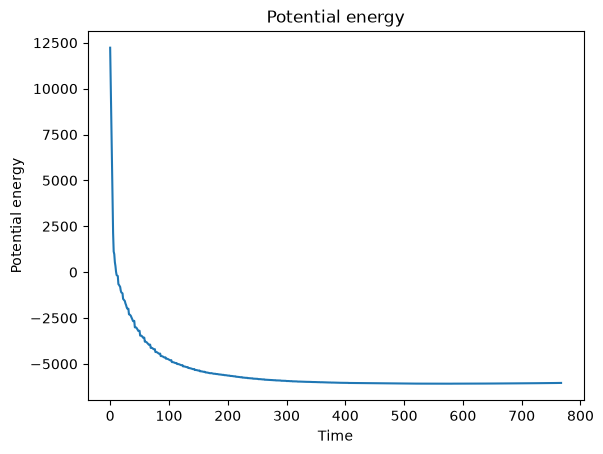

In [27]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt(
    "lysozyme_tutorial/potential.xvg",
    comments=["#", "@"]
)

time = data[:, 0]
energy = data[:, 1]

plt.plot(time, energy)
plt.xlabel("Time")
plt.ylabel("Potential energy")
plt.title("Potential energy")
plt.savefig(
    "lysozyme-md-simulation/figures/Penergy.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

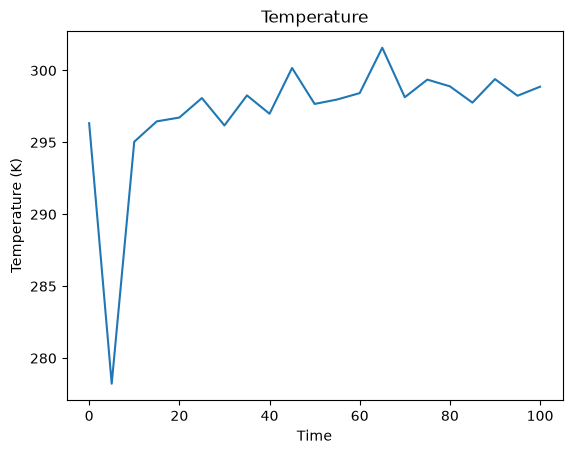

In [26]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt(
    "lysozyme_tutorial/temperature.xvg",
    comments=["#", "@"]
)

time = data[:, 0]
energy = data[:, 1]

plt.plot(time, energy)
plt.xlabel("Time")
plt.ylabel("Temperature (K)")
plt.title("Temperature")
plt.savefig(
    "lysozyme-md-simulation/figures/temperature.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

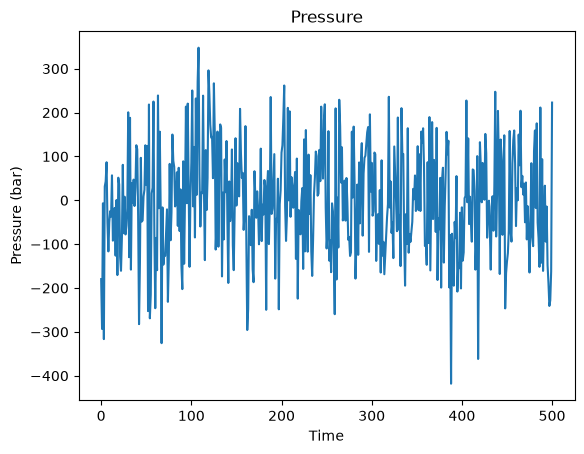

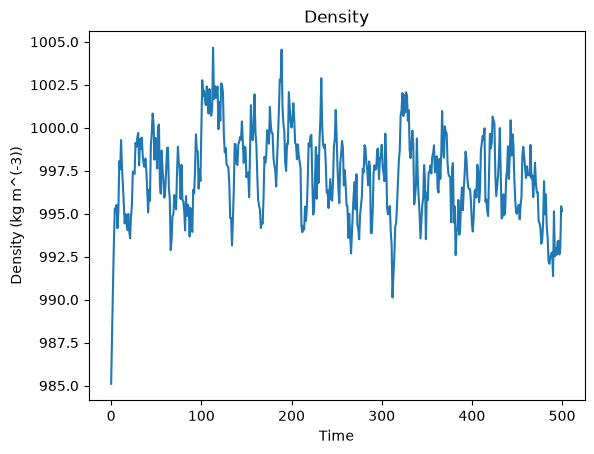

In [25]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt(
    "lysozyme_tutorial/pressure.xvg",
    comments=["#", "@"]
)

time = data[:, 0]
energy = data[:, 1]

plt.plot(time, energy)
plt.xlabel("Time")
plt.ylabel("Pressure (bar)")
plt.title("Pressure")

plt.savefig(
    "lysozyme-md-simulation/figures/pressure.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

data = np.loadtxt(
    "lysozyme_tutorial/density.xvg",
    comments=["#", "@"]
)

time = data[:, 0]
energy = data[:, 1]

plt.plot(time, energy)
plt.xlabel("Time")
plt.ylabel("Density (kg m^(-3))")
plt.title("Density")
plt.savefig(
    "lysozyme-md-simulation/figures/density.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

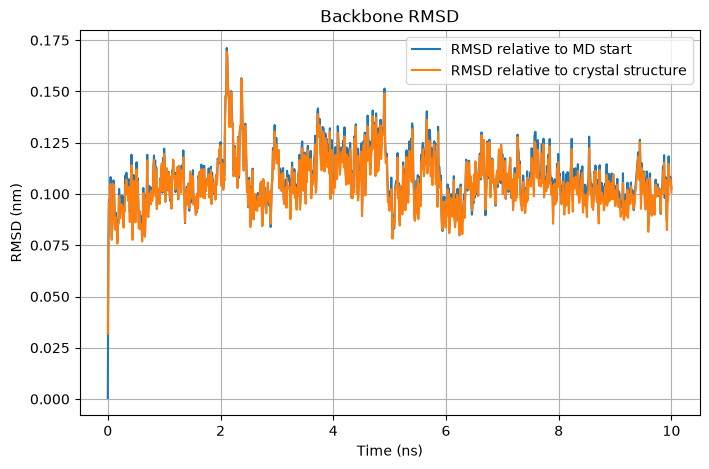

In [21]:
import numpy as np
import matplotlib.pyplot as plt

rmsd = np.loadtxt("lysozyme_tutorial/rmsd.xvg", comments=["#", "@"])
rmsd_xtal = np.loadtxt("lysozyme_tutorial/rmsd_xtal.xvg", comments=["#", "@"])

plt.figure(figsize=(8, 5))

plt.plot(rmsd[:, 0], rmsd[:, 1], label="RMSD relative to MD start")
plt.plot(rmsd_xtal[:, 0], rmsd_xtal[:, 1], label="RMSD relative to crystal structure")

plt.xlabel("Time (ns)")
plt.ylabel("RMSD (nm)")
plt.title("Backbone RMSD")
plt.legend()
plt.grid()

plt.savefig(
    "lysozyme-md-simulation/figures/rmsd.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [11]:
import numpy as np
import matplotlib.pyplot as plt


def read_xvg(filename):
    return np.loadtxt(
        filename,
        comments=("#", "@"),
        ndmin=2
    )


def plot_xvg(filename, title, ylabel):
    data = read_xvg(filename)

    plt.figure(figsize=(8, 5))
    plt.plot(data[:, 0], data[:, 1])

    plt.xlabel("Time (ns)")
    plt.ylabel(ylabel)
    plt.title(title)

    plt.grid()
    plt.show()

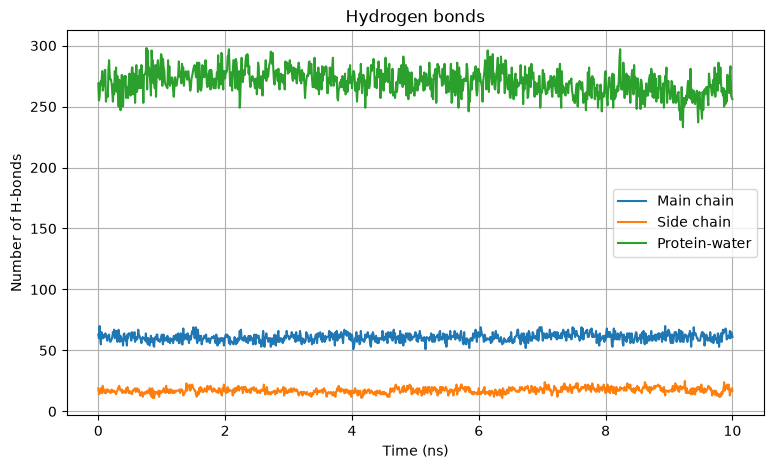

In [24]:
mainchain = read_xvg("lysozyme_tutorial/hbnum_mainchain.xvg")
sidechain = read_xvg("lysozyme_tutorial/hbnum_sidechain.xvg")
prot_wat = read_xvg("lysozyme_tutorial/hbnum_prot_wat.xvg")

plt.figure(figsize=(9, 5))

plt.plot(
    mainchain[:, 0],
    mainchain[:, 1],
    label="Main chain"
)

plt.plot(
    sidechain[:, 0],
    sidechain[:, 1],
    label="Side chain"
)

plt.plot(
    prot_wat[:, 0],
    prot_wat[:, 1],
    label="Protein-water"
)

plt.xlabel("Time (ns)")
plt.ylabel("Number of H-bonds")
plt.title("Hydrogen bonds")
plt.legend()
plt.grid()

plt.savefig(
    "lysozyme-md-simulation/figures/hbonds.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

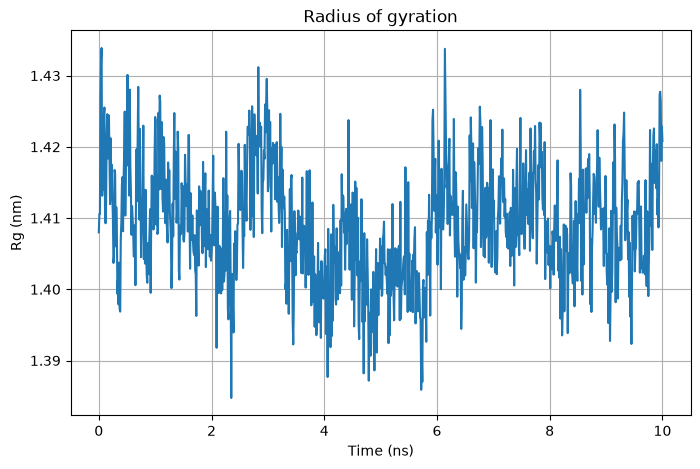

<Figure size 640x480 with 0 Axes>

In [ ]:
plot_xvg(
    "lysozyme_tutorial/gyrate.xvg",
    "Radius of gyration",
    "Rg (nm)"
)

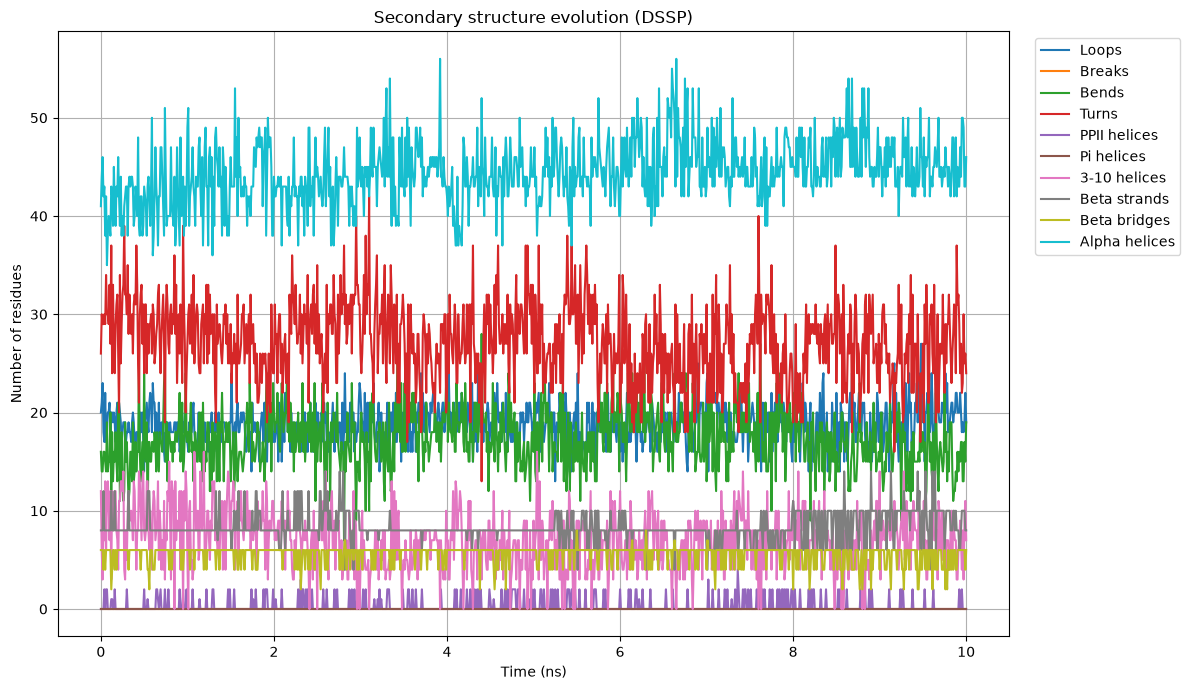

In [23]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt(
    "lysozyme_tutorial/dssp_num.xvg",
    comments=("#", "@")
)

time = data[:, 0]

labels = [
    "Loops",
    "Breaks",
    "Bends",
    "Turns",
    "PPII helices",
    "Pi helices",
    "3-10 helices",
    "Beta strands",
    "Beta bridges",
    "Alpha helices"
]

plt.figure(figsize=(12, 7))

for i, label in enumerate(labels, start=1):
    plt.plot(
        time,
        data[:, i],
        label=label
    )

plt.xlabel("Time (ns)")
plt.ylabel("Number of residues")
plt.title("Secondary structure evolution (DSSP)")
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.grid()

plt.tight_layout()
plt.savefig(
    "lysozyme-md-simulation/figures/dssp.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()